## APhys Group Meeting (24/6/2026)

In [1]:
# imports
import ewgreaders as ewg
import ewgdatsci as dsi
import xarray as xr
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from tqdm.notebook import tqdm

In [2]:
lake = 'Zug'

breader = ewg.bathy_reader.BathyReader(lake)
bathy = breader.load()

di_ctd = ewg.get_data_index(lake, 'ctd')
di_m = ewg.get_data_index(lake, 'mooring')

c:\Users\herremha\AppData\Local\anaconda3\envs\ewg\Lib\site-packages\xarray\backends\plugins.py:110: RuntimeWarning: Engine 'gini' loading failed:
DLL load failed while importing _context: The specified module could not be found.
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


In [3]:
def ch1903_to_latlng(xsc, ysc):
    # remove leading 2 (xsc) and 1 (ysc)
    if xsc > 2e6:
        xsc = xsc - int(2e6)
    if ysc > 1e6:
        ysc = ysc - int(1e6)

    x = (xsc - 600000) / 1000000
    y = (ysc - 200000) / 1000000

    lat = (16.9023892 
        + 3.238272 * y 
        - 0.270978 * x ** 2 
        - 0.002528 * y ** 2 
        - 0.0447 * x ** 2 * y 
        - 0.014 * y ** 3)
    
    lng = (2.6779094 
        + 4.728982 * x 
        + 0.791484 * x * y 
        + 0.1306 * x * y ** 2 
        - 0.0436 * x ** 3)
    
    lat = (lat * 100) / 36
    lng = (lng * 100) / 36

    return lat, lng

In [4]:
# LZW location
xw, yw = (2679917, 1218754)
lat, lng = ch1903_to_latlng(xw, yw)

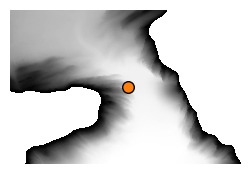

In [30]:
bathy_sel = bathy.sel(xsc=slice(2678500, 2681300), ysc=slice(1217500, 1220000))

fig, ax = plt.subplots(figsize=(3, 2))

im = ax.pcolormesh(bathy_sel['xsc'], bathy_sel['ysc'], bathy_sel['depth'], cmap='Greys_r', vmin=0, rasterized=True)

ax.scatter(xw, yw, s=70, c='tab:orange', edgecolor='black')

ax.set_xticks([])
ax.set_yticks([])
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

plt.savefig('../gallery/aphys/2026_06_24/map_w.svg', bbox_inches='tight')
plt.show()

### Bathymetry transects

In [5]:
ymin = 1218000
ymax = 1219000

angles = [80, 90, 100]
palette = sns.color_palette('Oranges_r', n_colors=2*len(angles))[::2]

In [6]:
def bathy_transect(bathy, x0, y0, angle, ymin, ymax):
    angle_rad = np.deg2rad(angle)

    transect = [{'xsc': x0, 'ysc': y0, 'depth': bathy.sel(xsc=x0, ysc=y0, method='nearest').depth.item()}]

    # to N edge of constriction
    x, y = (x0, y0)
    while y < ymax:
        x = x + np.cos(angle_rad)
        y = y + np.sin(angle_rad)
        depth = bathy.sel(xsc=x, ysc=y, method='nearest').depth.item()
        transect.append({'xsc': x, 'ysc': y, 'depth': depth})

    # to S edge of constriction
    x, y = (x0, y0)
    while y > ymin:
        x = x - np.cos(angle_rad)
        y = y - np.sin(angle_rad)
        depth = bathy.sel(xsc=x, ysc=y, method='nearest').depth.item()
        transect.insert(0, {'xsc': x, 'ysc': y, 'depth': depth})        # maintain S to N order

    transect = pd.DataFrame(transect)
    transect['angle'] = angle
    transect['distance'] = np.arange(len(transect))    # 1 meter spacing
    
    return transect

In [7]:
transect_data = []
for angle in angles:
    df = bathy_transect(bathy, xw, yw, angle, ymin, ymax)
    transect_data.append(df)

transect_data = pd.concat(transect_data, ignore_index=True)

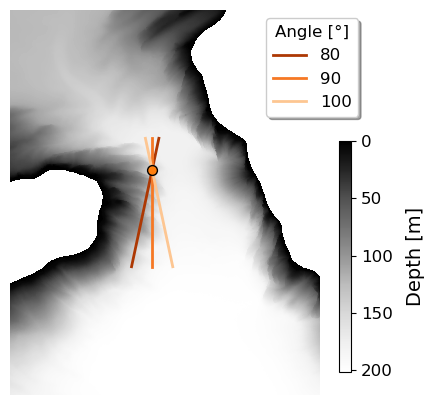

In [ ]:
bathy_sel = bathy.sel(xsc=slice(2679000, 2681000), ysc=slice(1217000, 1220000))

fig, ax = plt.subplots(figsize=(5, 5))

im = ax.pcolormesh(bathy_sel['xsc'], bathy_sel['ysc'], bathy_sel['depth'], cmap='Greys_r', vmin=0, rasterized=True)
cbar = fig.colorbar(im, shrink=0.6, anchor=(0.0, 0.15), ax=ax)
cbar.set_label('Depth [m]', fontsize=14, labelpad=10)
cbar.ax.tick_params(labelsize=12)
cbar.ax.invert_yaxis()

sns.lineplot(transect_data, x='xsc', y='ysc', orient='y', hue='angle', palette=palette, lw=2, ax=ax)
ax.scatter(xw, yw, color='tab:orange', s=50, edgecolor='k', zorder=3)

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([])
ax.set_yticks([])
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)


ax.legend(title='Angle [°]', fontsize=12, title_fontsize=12, ncols=1, shadow=True, loc='upper right', bbox_to_anchor=(1.15, 1))

plt.savefig('../gallery/aphys/2026_06_24/map_transects.svg', bbox_inches='tight')
plt.show()

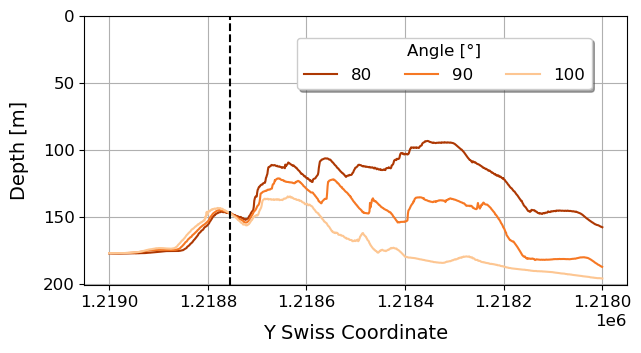

In [27]:
fig, ax = plt.subplots(figsize=(7, 3.5))

sns.lineplot(transect_data, x='ysc', y='depth', hue='angle', palette=palette, ax=ax)

ax.axvline(yw, color='black', linestyle='--')
ax.set_xlabel('Y Swiss Coordinate', fontsize=14, labelpad=10)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax.set_title('')
ax.tick_params(axis='both', labelsize=12)
ax.xaxis.get_offset_text().set_fontsize(12)

ax.set_ylim(0, None)
ax.grid(True)
#ax.spines[['right', 'top']].set_visible(False)
ax.invert_xaxis()
ax.invert_yaxis()

ax.legend(title='Angle [°]', fontsize=12, title_fontsize=12, ncols=3, shadow=True, loc='upper right', bbox_to_anchor=(0.95, 0.95))

plt.savefig('../gallery/aphys/2026_06_24/bathy_transects.svg', bbox_inches='tight')
plt.show()    

In [11]:
wavenum_data = []
for ang, dat in transect_data.groupby("angle"):
    freqs, psd = scipy.signal.welch(dat.depth.values, fs=1, nperseg=len(dat), detrend='linear', scaling='density')
    freqs = freqs[1:]
    wavenum = 2 * np.pi * freqs
    psd = psd[1:]

    data = pd.DataFrame({
        'frequency': freqs,
        'wavenum': wavenum,
        'psd': psd
    })
    data['angle'] = ang
    wavenum_data.append(data)

wavenum_data = pd.concat(wavenum_data, ignore_index=True)

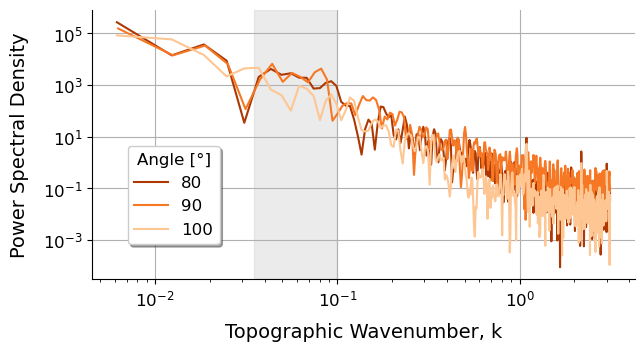

In [26]:
fig, ax = plt.subplots(figsize=(7, 3.5))

ax.axvspan(0.035, 0.1, color='silver', alpha=0.3)
sns.lineplot(wavenum_data, x='wavenum', y='psd', hue='angle', palette=palette, ax=ax)

ax.set_xlabel('Topographic Wavenumber, k', fontsize=14, labelpad=10)
ax.set_ylabel('Power Spectral Density', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)

ax.set_xscale('log')
ax.set_yscale('log')
ax.spines[['right', 'top']].set_visible(False)

ax.grid(True)
ax.legend(title='Angle [°]', fontsize=12, title_fontsize=12, ncols=1, shadow=True, loc='lower left', bbox_to_anchor=(0.05, 0.1))

plt.savefig('../gallery/aphys/2026_06_24/wavenum_k.svg', bbox_inches='tight')
plt.show()

In [261]:
(2 * np.pi) / 0.035, (2 * np.pi) / 0.1

(179.519580205131, 62.83185307179586)

In [8]:
mask = wavenum > 0.04
idx = np.argmax(pows[mask])

k_char = wavenum[mask][idx]
lmda_char = (2 * np.pi) / k_char

k_char, lmda_char

(np.float64(0.04393835879146564), np.float64(143.0))

### Current Velocity

In [13]:
t_start = '2026-02-06'
t_end = '2026-04-08'

date = '2026-04-09'
loc = 'LZW'
sensor = 'adcp'
row = di_m.query("date == @date and location == @loc and sensor == @sensor").iloc[0]

areader = ewg.adcp_reader.ADCPReader(row.lake, row.date, row.location, row.serial_id)
ds_w = areader.load().sel(time=slice(t_start, t_end))

C:\Users\herremha\AppData\Local\Temp\ipykernel_32092\251384086.py:7: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  row = di_m.query("date == @date and location == @loc and sensor == @sensor").iloc[0]


### Buoyancy Frequency

In [14]:
pl_w = ["P6W", "VMPW"]

di_ctd_sel = di_ctd[di_ctd['profile_loc'].isin(pl_w) & (di_ctd['date'].between(t_start, t_end))]

In [15]:
# depth range from ADCP (bottom 10 meters)
z_min = ds_w.depth.max().item() - 10
z_max = ds_w.depth.max().item()

N2_data = []
for i, p in tqdm(di_ctd_sel.iterrows(), total=len(di_ctd_sel)):
    ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
    ds = ctdreader.load()

    if ds['depth'].max().item() > (z_max + z_min) / 2:
        # buoyancy frequency
        rho_ba = dsi.signal.binned_average_z(ds['rho'], 1)    # 1 meter binned average
        rho_ba_sort = dsi.signal.order_profile(rho_ba, surfmax=False, reassign_depth=True)
        N2 = dsi.efd.brunt_vaisala_frequency(rho_ba_sort)
        
        # select depth range from ADCP
        N2 = N2.sel(depth=slice(120, z_max)).to_dataframe().reset_index()
        N2[['date', 'time', 'idx']] = p.date, p.time, i
        N2_data.append(N2)

N2_data = pd.concat(N2_data, ignore_index=True)

  0%|          | 0/9 [00:00<?, ?it/s]

In [16]:
# average over depth for each profile
N2_pavg = N2_data.groupby(['date', 'time'])['N2'].mean().reset_index()

# average across profiles for each date
N2_davg = N2_pavg.groupby('date')['N2'].mean().reset_index()

N = np.sqrt(N2_davg['N2'].mean())
N

np.float64(0.0009067721153116623)

### Inverse Froude number and intrinsic frequency

In [29]:
# Coriolis frequency
f = 2 * 7.29e-5 * np.sin(np.deg2rad(lat))

# characteristic topographic wavenumber
k = (0.035 + 0.1) / 2

f, k

(np.float64(0.000106830651382675), 0.0675)

In [18]:
res = []
for ang, dat in transect_data.groupby("angle"):
    h = dat.depth.max() - dat.depth.min()
    
    # project velocity along angle
    vel = dsi.signal.velocity_projection(ds_w.vel, ang).sel(depth=slice(None, z_min))

    # mask for velocity in same direction all depths
    mask = vel.min(dim='depth') * vel.max(dim='depth') > 0

    # average over depth
    U = vel.where(mask, drop=True).mean(dim='depth')

    freq_intr = U * k
    F_inv = N * h / U

    print(ang, N, h, k)

    data = pd.DataFrame({
        'angle': ang,
        'time': U.time,
        'vel': U,
        'freq_intr': freq_intr,
        'F_inv': F_inv
    })
    res.append(data)

res_df = pd.concat(res, ignore_index=True).sort_values(['angle', 'time'])
res_df[['abs_vel', 'abs_freq_intr', 'abs_F_inv']] = abs(res_df[['vel', 'freq_intr', 'F_inv']])

80 0.0009067721153116623 84.20002 0.0675
90 0.0009067721153116623 66.12001000000001 0.0675
100 0.0009067721153116623 61.32000000000002 0.0675


In [19]:
res = []
for ang, dat in res_df.groupby('angle'):
    ds = xr.Dataset(dat.drop(columns='angle').set_index('time'))
    ds = ds.expand_dims(angle=[ang])
    res.append(ds)

res_ds = xr.concat(res, dim='angle', join='outer')

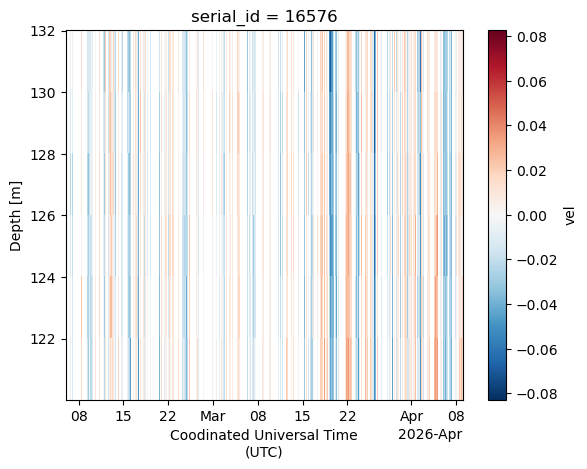

In [20]:
vel.where(mask).plot()

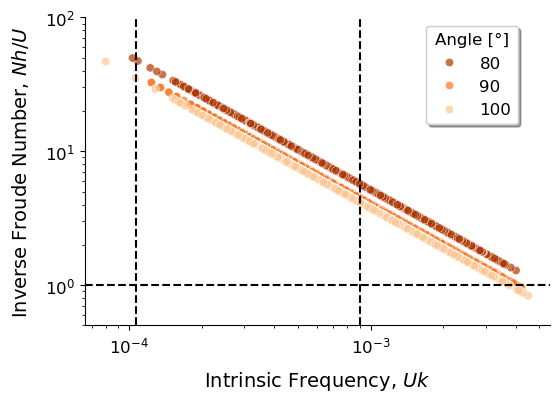

In [21]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.axhline(1, color='black', linestyle='--')
ax.axvline(N, color='black', linestyle='--')
ax.axvline(f, color='black', linestyle='--')
sns.scatterplot(res_df, x='abs_freq_intr', y='abs_F_inv', hue='angle', palette=palette, alpha=0.7, ax=ax)

ax.set_xlabel('Intrinsic Frequency, ' + r'$Uk$', fontsize=14, labelpad=10)
ax.set_ylabel('Inverse Froude Number, ' + r'$Nh/U$', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(0.5e-0, 1e2)

ax.legend(title='Angle [°]', fontsize=12, title_fontsize=12, ncols=1, shadow=True, loc='upper right', bbox_to_anchor=(0.95, 1))

plt.savefig('../gallery/aphys/2026_06_24/regime.svg', bbox_inches='tight')
plt.show()

In [22]:
mask = (res_df['abs_freq_intr'] > N) & (res_df['abs_F_inv'] < 1)
res_df[mask]

,angle,time,vel,freq_intr,F_inv,abs_vel,abs_freq_intr,abs_F_inv
7187,90,2026-03-26 04:06:08.029999971,-0.061667,-0.004162,-0.972256,0.061667,0.004162,0.972256
7189,90,2026-03-26 04:26:08.029999971,-0.062500,-0.004219,-0.959293,0.062500,0.004219,0.959293
10924,100,2026-03-19 08:36:08.029999971,-0.055812,-0.003767,-0.996266,0.055812,0.003767,0.996266
11526,100,2026-03-26 04:06:08.029999971,-0.062206,-0.004199,-0.893860,0.062206,0.004199,0.893860
11528,100,2026-03-26 04:26:08.029999971,-0.066702,-0.004502,-0.833607,0.066702,0.004502,0.833607
11529,100,2026-03-26 04:36:08.029999971,-0.061152,-0.004128,-0.909269,0.061152,0.004128,0.909269
11530,100,2026-03-26 04:46:08.029999971,-0.063603,-0.004293,-0.874231,0.063603,0.004293,0.874231
11531,100,2026-03-26 04:56:08.029999971,-0.059528,-0.004018,-0.934061,0.059528,0.004018,0.934061
11532,100,2026-03-26 05:06:08.029999971,-0.060388,-0.004076,-0.920766,0.060388,0.004076,0.920766
11533,100,2026-03-26 05:16:08.029999971,-0.061730,-0.004167,-0.900749,0.061730,0.004167,0.900749


### Thorpe displacement

In [23]:
thorpe_data = []
for _, p in tqdm(di_ctd_sel.iterrows(), total=len(di_ctd_sel)):
    ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
    ds = ctdreader.load()

    # thorpe displacement
    rho = ds['rho']
    depth = ds['depth']
    rho_ra = dsi.signal.rolling_average_z(rho, ra_window=1)
    rho_ra_sort = dsi.signal.order_profile(rho_ra, surfmax=False, reassign_depth=False)
    thorpe_displacement = depth - rho_ra_sort.depth.values
    thorpe_scale = np.sqrt((thorpe_displacement**2).mean()).item()

    data = pd.DataFrame({
        'date': p.date,
        'time_local': p.time,
        'time_utc': ds.time.values,
        'depth': depth.values,
        'thorpe': thorpe_displacement.values
    })
    thorpe_data.append(data)

thorpe_data = pd.concat(thorpe_data, ignore_index=True)

  0%|          | 0/9 [00:00<?, ?it/s]

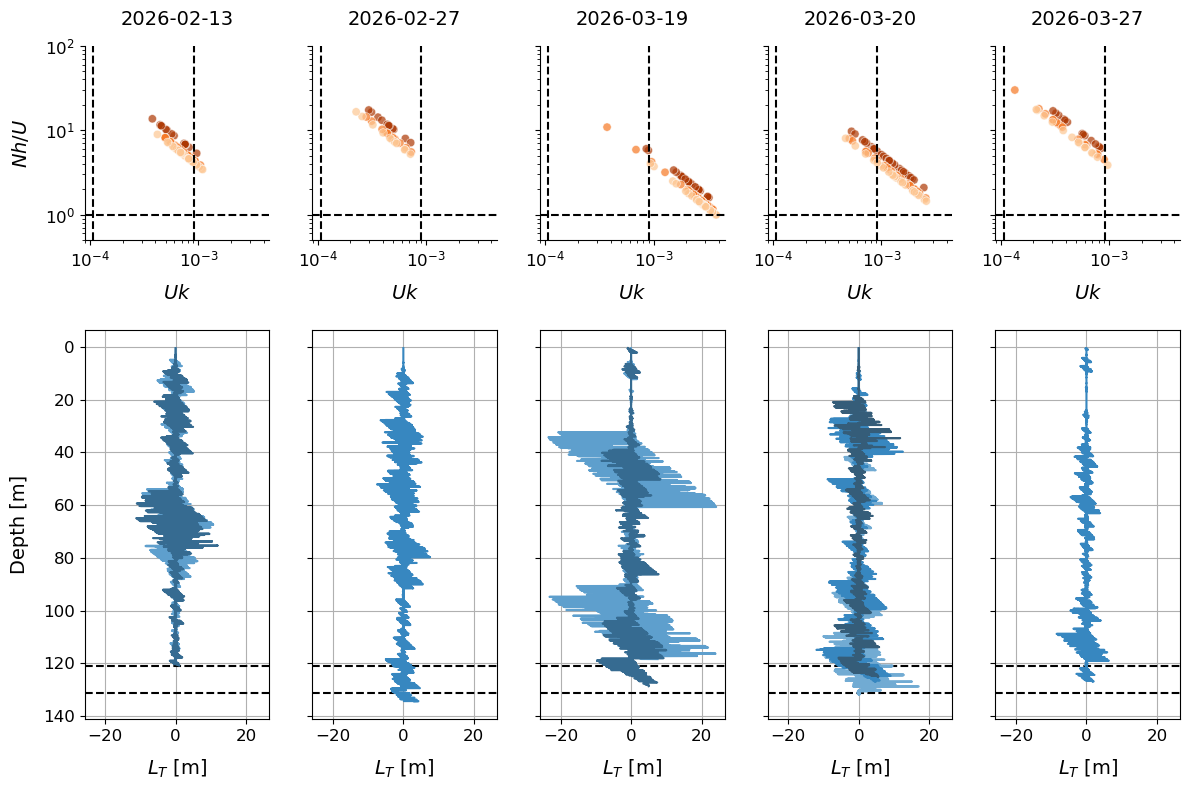

In [24]:
fig, ax = plt.subplots(nrows=2, ncols=thorpe_data.date.nunique(), figsize=(12, 8), sharex='row', sharey='row', height_ratios=[1, 2])

for i, (dt, dat) in enumerate(thorpe_data.groupby('date')):
    # select data from 6 hours prior to CTD profiles
    t0 = dat.time_utc.min() - pd.Timedelta(hours=6)
    tf = dat.time_utc.max()
    df = res_df[res_df['time'].between(t0, tf)]

    # intrinsic frequency and inverse froude number
    ax[0, i].axhline(1, color='black', linestyle='--')
    ax[0, i].axvline(N, color='black', linestyle='--')
    ax[0, i].axvline(f, color='black', linestyle='--')
    sns.scatterplot(df, x='abs_freq_intr', y='abs_F_inv', hue='angle', palette=palette, alpha=0.7, ax=ax[0, i], legend=False)

    ax[0, i].set_xlabel(r'$Uk$', fontsize=14, labelpad=10)
    ax[0, i].set_ylabel(r'$Nh/U$', fontsize=14, labelpad=10)
    ax[0, i].set_title(dt.date(), fontsize=14, pad=15)
    ax[0, i].tick_params(axis='both', labelsize=12)

    ax[0, i].spines[['right', 'top']].set_visible(False)
    ax[0, i].set_xscale('log')
    ax[0, i].set_yscale('log')
    ax[0, i].set_ylim(0.5e-0, 1e2)

    # thorpe displacement
    ax[1, i].axhline(z_min, color='black', linestyle='--')
    ax[1, i].axhline(z_max, color='black', linestyle='--')
    sns.lineplot(dat, x='thorpe', y='depth', orient='y', hue='time_local', ax=ax[1, i], palette='Blues_d', legend=False)

    ax[1, i].set_xlabel(r'$L_{T}$ [m]', fontsize=14, labelpad=10)
    ax[1, i].tick_params(axis='both', labelsize=12)
    ax[1, i].grid(True)

ax[1, 0].set_ylabel('Depth [m]', fontsize=14, labelpad=10)

ax[1, 0].invert_yaxis()

plt.tight_layout(h_pad=2, w_pad=2)
plt.savefig('../gallery/aphys/2026_06_24/regime_thorpe.svg', bbox_inches='tight')
plt.show()

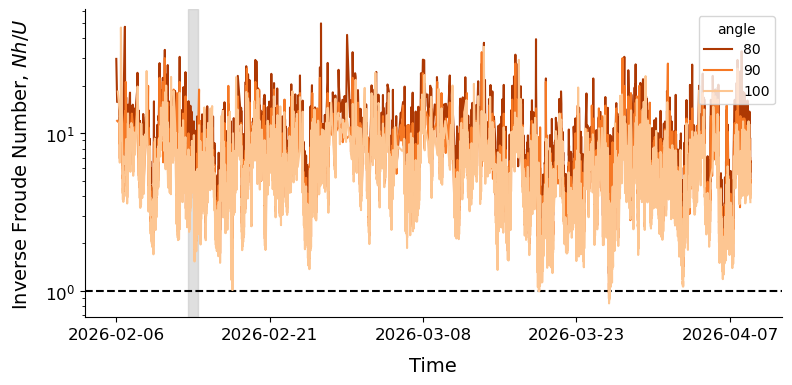

In [875]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.axvspan(pd.to_datetime('2026-02-13 00:00:00'), pd.to_datetime('2026-02-14 00:00:00'), color='silver', alpha=0.5)
ax.axhline(1, color='black', linestyle='--')
sns.lineplot(res_df, x='time', y='abs_F_inv', hue='angle', palette=palette, ax=ax)

ax.set_xlabel('Time', fontsize=14, labelpad=10)
ax.set_ylabel('Inverse Froude Number, ' + r'$Nh/U$', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=15))

ax.set_yscale('log')
ax.spines[['right', 'top']].set_visible(False)

plt.show()

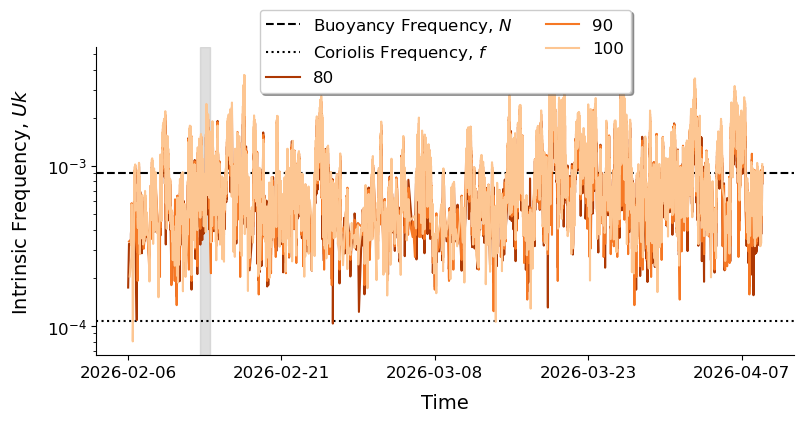

In [877]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.axvspan(pd.to_datetime('2026-02-13 00:00:00'), pd.to_datetime('2026-02-14 00:00:00'), color='silver', alpha=0.5)
ax.axhline(N, color='black', linestyle='--', label=r'Buoyancy Frequency, $N$')
ax.axhline(f, color='black', linestyle=':', label=r'Coriolis Frequency, $f$')
sns.lineplot(res_df, x='time', y='abs_freq_intr', hue='angle', palette=palette, ax=ax)

ax.set_xlabel('Time', fontsize=14, labelpad=10)
ax.set_ylabel('Intrinsic Frequency, ' + r'$Uk$', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=15))

ax.set_yscale('log')
ax.spines[['right', 'top']].set_visible(False)

ax.legend(fontsize=12, ncols=2, shadow=True, loc='upper center', bbox_to_anchor=(0.5, 1.15))

plt.show()

### Workspace

In [14]:
h = 180 - 125
N = 1e-3
k = (0.0815 + 0.0439) / 2    # average of two peaks
f = 2 * 7.29e-5 * np.sin(np.deg2rad(47.16))
U = 5e-2

F_inv = N * h / U
freq_intr = U * k


In [17]:
f < freq_intr > N

True